In [1]:
#Import the usual library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import random

# Association

In [2]:
np.random.RandomState(10)

RandomState(MT19937) at 0x1259C9E8

In [3]:
x = list(np.random.normal(5,2,100))
x = [round(i,2) for i in x]

y = [(3 + 3*i + np.asscalar(np.random.normal(0,1.5,1))) for i in x]
y = [round(i,2) for i in y]

<ipython-input-3-4de45c9e4f37>:4: DeprecationWarning: np.asscalar(a) is deprecated since NumPy v1.16, use a.item() instead
  y = [(3 + 3*i + np.asscalar(np.random.normal(0,1.5,1))) for i in x]


In [4]:
y2 = [i**4 for i in y]

In [5]:
df_assotiation = pd.DataFrame({
    'x':x,
    'y':y,
    'y2':y2
})

In [6]:
df_assotiation.head(10)

,x,y,y2
0,6.52,24.27,346959.757282
1,0.72,4.94,595.535693
2,7.59,26.37,483549.033054
3,8.35,28.80,687970.713600
4,5.68,20.02,160640.960640
5,3.78,12.75,26426.566406
6,4.53,16.82,80039.426074
7,2.69,12.31,22963.189603
8,3.30,11.35,16595.236506
9,6.86,23.34,296758.663731


## Linear

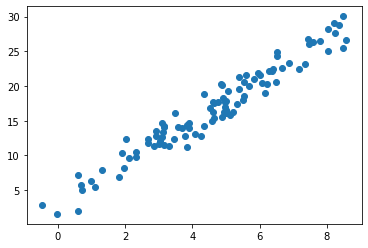

In [7]:
plt.scatter(x,y)

In [8]:
df_assotiation[['x','y']].corr()

,x,y
x,1.000000,0.972063
y,0.972063,1.000000


## Non-Linear Monotonic

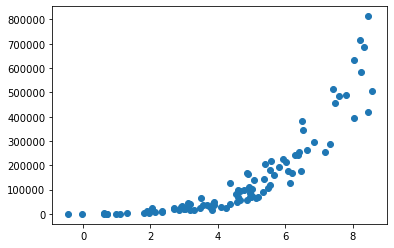

In [9]:
plt.scatter(x,y2)

In [10]:
df_assotiation[['x','y']].corr(method = 'spearman')

,x,y
x,1.000000,0.966593
y,0.966593,1.000000


## Non-Linear Non-Monotonic

In [11]:
np.random.RandomState(10)

RandomState(MT19937) at 0x1259CAB8

In [12]:
x = list(np.random.normal(0,10,100))
x = [round(i,2) for i in x]

y = [(4 - i**2 + np.asscalar(np.random.normal(0,10,1))) for i in x]
y = [round(i,2) for i in y]

<ipython-input-12-a36a3868f059>:4: DeprecationWarning: np.asscalar(a) is deprecated since NumPy v1.16, use a.item() instead
  y = [(4 - i**2 + np.asscalar(np.random.normal(0,10,1))) for i in x]


In [13]:
df_assotiation2 = pd.DataFrame({
    'x':x,
    'y':y
})

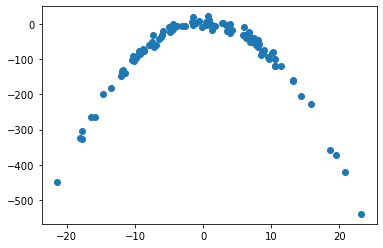

In [14]:
plt.scatter(x,y)

In [15]:
df_assotiation2[['x','y']].corr(method = 'spearman')

,x,y
x,1.000000,0.025317
y,0.025317,1.000000


In [16]:
df_assotiation2[['x','y']].corr(method = 'pearson')

,x,y
x,1.000000,-0.012655
y,-0.012655,1.000000


from this illustration :
1. when using spearman or pearson and the reult is almost zero. it doesn't mean that there is no association or weak association
1. there is till might an association but in another form of relationship (in this case is quadratics)
1. that is why graphical summary is very important

## Crime Rate vs Education

Education =  Education was measured as the percentage of residents aged at least 25 in the county who had at least a high school degree. 
<br>
Crime Rate =  Crime rate was measured as the number of crimes in that county in the past year per 1000 residents. 
<br>
County Type = Rural or Urban

In [17]:
df_urban = pd.DataFrame({
    'Education':[70,75,80,85],
    'Crime rate':[140,120,110,105],
    'county type':'urban'
})

df_rural = pd.DataFrame({
    'Education':[55,58,60,65],
    'Crime rate':[50,40,30,25],
    'county type':'rural'    
})

In [18]:
df_counties = df_urban.append(df_rural)

### Analyze marginaly

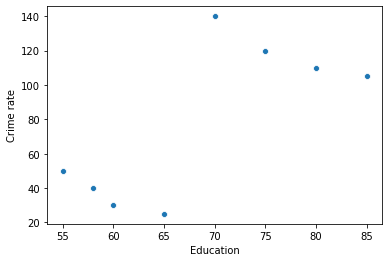

In [19]:
sns.scatterplot(x='Education',y='Crime rate',data=df_counties)

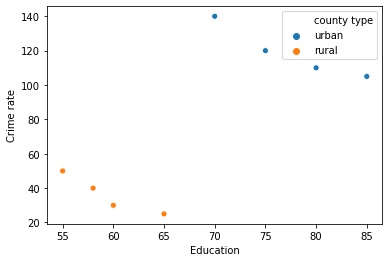

In [20]:
sns.scatterplot(x='Education',y='Crime rate',data=df_counties,hue='county type')

In [21]:
df_counties.corr()

,Education,Crime rate
Education,1.000000,0.731798
Crime rate,0.731798,1.000000


The correlation between education and crime rate is highly positive. Is that make sense that crime rate increasing when education level increase ?

In [22]:
df_counties

,Education,Crime rate,county type
0,70,140,urban
1,75,120,urban
2,80,110,urban
3,85,105,urban
0,55,50,rural
1,58,40,rural
2,60,30,rural
3,65,25,rural


In [23]:
# transforming county type into ordinal scale
df_counties['county type encode'] = df_counties['county type'].map({'rural':0,'urban':1})

In [24]:
df_counties

,Education,Crime rate,county type,county type encode
0,70,140,urban,1
1,75,120,urban,1
2,80,110,urban,1
3,85,105,urban,1
0,55,50,rural,0
1,58,40,rural,0
2,60,30,rural,0
3,65,25,rural,0


In [25]:
df_counties.corr(method='spearman')

,Education,Crime rate,county type encode
Education,1.000000,0.523810,0.872872
Crime rate,0.523810,1.000000,0.872872
county type encode,0.872872,0.872872,1.000000


it turns out that each of education and crime rate are also correlated with urbanization.
1. highly urban counties tend to have higher crime rate.
1. highly urban counties tend to have higher education.
1. perhaps, perhaps the reason for the positive correlation between education and crime rate is that education tends to be greater in more highly urbanized counties and crime rates also tend to be higher in such counties.
1. another reason may be because of another covariate/lurking variable (ex. unemployment rate in such countries) in such counties.  
1. summary,  a correlation could occur without any causal connection.

### Analyze Partially

> #### Urban

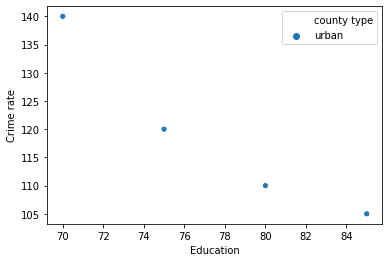

In [26]:
sns.scatterplot(x='Education',y='Crime rate',data=df_urban,hue='county type')

In [27]:
df_urban.corr()

,Education,Crime rate
Education,1.000000,-0.959166
Crime rate,-0.959166,1.000000


> #### Rural

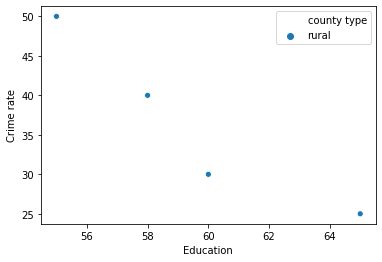

In [28]:
sns.scatterplot(x='Education',y='Crime rate',data=df_rural,hue='county type')

In [29]:
df_rural.corr()

,Education,Crime rate
Education,1.00000,-0.94779
Crime rate,-0.94779,1.00000


when we analyzing the data partially we found that the correlation between Education and Crime Rate is highly negative. This insight is against the insight that we got when we analyzing the data marginally. We cannot ignore another information such as urbanization.

## Death Penalty and Race

In [30]:
outside = ['White','White','Black','Black']
inside = ['White','Black','White','Black']
# hier_index = list(zip(outside,inside))
# hier_index = pd.MultiIndex.from_tuples(hier_index)

death_yes = [53,11,0,4]
death_no = [414,37,16,139]

In [31]:
df_death_penalty = pd.DataFrame({
    "victim's race":outside,
    "Defendant's race":inside,
    'death penalty(yes)':death_yes,
    'death penalty(no)':death_no}
)

In [32]:
df_death_penalty['Total'] = df_death_penalty['death penalty(yes)'] + df_death_penalty['death penalty(no)']
df_death_penalty['death penalty(yes) percentage'] = df_death_penalty['death penalty(yes)']/df_death_penalty['Total']
df_death_penalty['death penalty(no) percentage'] = df_death_penalty['death penalty(no)']/df_death_penalty['Total']

In [33]:
df_death_penalty

,victim's race,Defendant's race,death penalty(yes),death penalty(no),Total,death penalty(yes) percentage,death penalty(no) percentage
0,White,White,53,414,467,0.113490,0.886510
1,White,Black,11,37,48,0.229167,0.770833
2,Black,White,0,16,16,0.000000,1.000000
3,Black,Black,4,139,143,0.027972,0.972028


### White Victim

In [34]:
df_death_penalty_copy = df_death_penalty.copy()
df_death_penalty_white = df_death_penalty_copy[df_death_penalty_copy["victim's race"]=='White']

In [35]:
df_death_penalty_white

,victim's race,Defendant's race,death penalty(yes),death penalty(no),Total,death penalty(yes) percentage,death penalty(no) percentage
0,White,White,53,414,467,0.113490,0.886510
1,White,Black,11,37,48,0.229167,0.770833


### Black Victim

In [36]:
df_death_penalty_copy = df_death_penalty.copy()
df_death_penalty_black = df_death_penalty_copy[df_death_penalty_copy["victim's race"]=='Black']

In [37]:
df_death_penalty_black

,victim's race,Defendant's race,death penalty(yes),death penalty(no),Total,death penalty(yes) percentage,death penalty(no) percentage
2,Black,White,0,16,16,0.000000,1.000000
3,Black,Black,4,139,143,0.027972,0.972028


### Ignore Victim's Race

In [38]:
df_death_penalty.drop(columns = ['death penalty(yes) percentage','death penalty(no) percentage'], inplace = True)
df_death_penalty

,victim's race,Defendant's race,death penalty(yes),death penalty(no),Total
0,White,White,53,414,467
1,White,Black,11,37,48
2,Black,White,0,16,16
3,Black,Black,4,139,143


In [39]:
df_death_penalty_pivot = df_death_penalty.pivot_table(index=["Defendant's race"], aggfunc = 'sum')
df_death_penalty_pivot = df_death_penalty_pivot[['death penalty(yes)','death penalty(no)','Total']]
df_death_penalty_pivot

,death penalty(yes),death penalty(no),Total
Defendant's race,,,
Black,15,176,191
White,53,430,483


In [40]:
df_death_penalty_pivot['Total'] = df_death_penalty_pivot['death penalty(yes)'] + df_death_penalty_pivot['death penalty(no)']
df_death_penalty_pivot['death penalty(yes) percentage'] = df_death_penalty_pivot['death penalty(yes)']/df_death_penalty_pivot['Total']
df_death_penalty_pivot['death penalty(no) percentage'] = df_death_penalty_pivot['death penalty(no)']/df_death_penalty_pivot['Total']
df_death_penalty_pivot

,death penalty(yes),death penalty(no),Total,death penalty(yes) percentage,death penalty(no) percentage
Defendant's race,,,,,
Black,15,176,191,0.078534,0.921466
White,53,430,483,0.109731,0.890269
